In [15]:
import pandas as pd

dataset = pd.read_csv("dataset/combined_dataset_11comorbdims_1wardcode.csv")

In [16]:
print(dataset.columns)

Index(['Unnamed: 0', 'anon_id', 'order_time_jittered_utc_shifted', 'resistant',
       'adi_score', 'age', 'gender', 'nursing_home_visit_culture',
       'last_dose_to_culture', 'drug_code', 'procedure_description',
       'procedure_days_culture', 'wards_int', 'Comorbidity_Reduced_Val_1',
       'Comorbidity_Reduced_Val_2', 'Comorbidity_Reduced_Val_3',
       'Comorbidity_Reduced_Val_4', 'Comorbidity_Reduced_Val_5',
       'Comorbidity_Reduced_Val_6', 'Comorbidity_Reduced_Val_7',
       'Comorbidity_Reduced_Val_8', 'Comorbidity_Reduced_Val_9',
       'Comorbidity_Reduced_Val_10', 'Comorbidity_Reduced_Val_11'],
      dtype='str')


In [ ]:
MODEL_CODE = "20features_efficientsu2map_realamplitudes3reps"
CONTINUE_TRAINING = False # Is this continued training from an existing model?
AUTO_SAVE = True # automatically save after training?
SAMPLES = 5000 # number of samples to train on
RESAMPLE = True # reduce number of samples to SAMPLES
OVERSAMPLE = False
UNDERSAMPLE = False

In [ ]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTENC
from sklearn.utils import resample
if UNDERSAMPLE:
    rs = RandomUnderSampler(sampling_strategy=1)

if OVERSAMPLE:
    cat_cols = list(dataset.drop(columns=['Unnamed: 0', 'anon_id','order_time_jittered_utc_shifted', 'resistant','adi_score','nursing_home_visit_culture', 'last_dose_to_culture','procedure_days_culture']).columns)
    rs = SMOTENC(categorical_features=cat_cols, sampling_strategy=1)


# pca = make_pipeline(
#     PCA(n_components=9)
# )

encoder = OrdinalEncoder()
X = dataset.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant", 'Unnamed: 0']).fillna(-9999999).astype(str)

# X = pca.fit_transform(X)

y = dataset["resistant"]

if OVERSAMPLE or UNDERSAMPLE:
    X_rs, y_rs = rs.fit_resample(X, y)
    y_rs = y_rs.to_numpy()
    X_rs = encoder.fit_transform(X_rs)

X = encoder.fit_transform(X)

# X = np.nan_to_num(X, -9999999)

y=y.to_numpy()




if RESAMPLE:
    X, y = resample(X, y, n_samples=SAMPLES, replace=False, stratify=y)
    if OVERSAMPLE or UNDERSAMPLE:
        X_rs, y_rs = resample(X_rs, y_rs, n_samples=SAMPLES, replace=False, stratify=y_rs)

if OVERSAMPLE or UNDERSAMPLE:
    X_train, X_test, y_train, y_test = train_test_split(X_rs, y_rs, test_size=0.2, stratify=y_rs)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(X, y, test_size=0.2, stratify=y)


In [19]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit.circuit.library import efficient_su2

num_features = X_train.shape[1]

reps = 1
num_qubits = int(num_features / (2*(reps+1))) # enable for efficient su2
# num_qubits = num_features # enable for zzfeaturemap

#feature_map = ZZFeatureMap(num_features)  
feature_map = efficient_su2(num_qubits=num_qubits, reps=reps, entanglement="full", parameter_prefix="f")



In [20]:
from qiskit.circuit.library import real_amplitudes
from qiskit.circuit.library import efficient_su2

log2features = int(np.log2(num_features)) # use with raw feature map

ansatz = real_amplitudes(num_qubits=num_qubits, reps=3, parameter_prefix="a")
# ansatz = efficient_su2(num_qubits=int(np.log2(num_features)), reps=3)

OPTIMIZER_ITERS = 100 #40 for efficient_su2 ansatz, 100 for real_amplitudes

In [21]:
from qiskit_machine_learning.optimizers import COBYLA

optimizer = COBYLA(maxiter=OPTIMIZER_ITERS)

In [22]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

In [23]:
from matplotlib import pyplot as plt
from IPython.display import clear_output

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)


def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

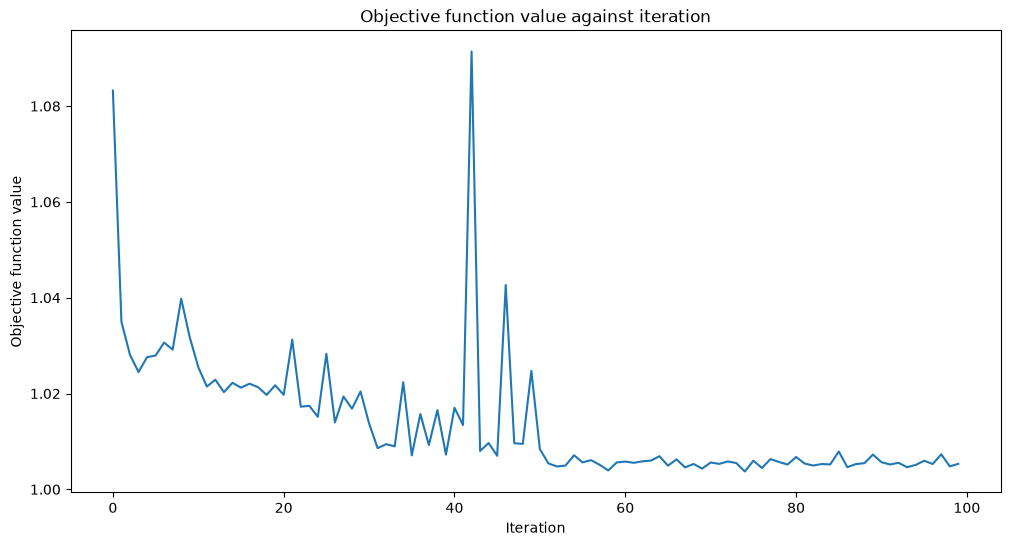

Training time: 2244 seconds


In [24]:
import time
from qiskit_machine_learning.algorithms.classifiers import VQC

if CONTINUE_TRAINING:
    vqc = VQC.from_dill(f"QML Models/{MODEL_CODE}.model")
    vqc.warm_start = True
    vqc.optimizer = optimizer
    vqc.sampler = sampler
else:
    vqc = VQC(
        sampler=sampler,
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback_graph,
    )

# clear objective value history
objective_func_vals = []

start = time.time()
vqc.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

In [25]:
if AUTO_SAVE:
    vqc.to_dill(f"QML Models/{MODEL_CODE}.model")

In [26]:
# train_score_q4 = vqc.score(X_train, y_train)
# test_score_q4 = vqc.score(X_test, y_test)

# print(f"Quantum VQC on the training dataset: {train_score_q4:.2f}")
# print(f"Quantum VQC on the test dataset:     {test_score_q4:.2f}")

In [27]:
# from sklearn.metrics import confusion_matrix

# y_pred = vqc.predict(X_test)

# tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
# print(f"True negatives: {tn} ({tn / len(y_test)})\n False positives: {fp} ({fp / len(y_test)})\n False negatives: {fn} ({fn / len(y_test)})\n True positives: {tp} ({tp / len(y_test)})")